In [1]:
using Pkg
Pkg.activate("./", io=devnull)
using Evaluation
using StatsPlots
using DataFrames
using CSV
using LaTeXStrings

In [2]:
function δ_bound_improvement(inst, target)
    if isinf(inst.initial_δ_bound) || isinf(inst.final_δ_bound)
        return 0.0
    end
    clamp(ifelse(inst.status .!= "UNKNOWN", 1.0, (inst.initial_δ_bound - inst.final_δ_bound) / (inst.initial_δ_bound - target)), 0.0, 1.0)
end

δ_bound_improvement (generic function with 1 method)

In [3]:
curr_dir = @__DIR__
exp_final_dir = joinpath(curr_dir, "..", "experiments", "experiments_final")

acas_name = "acas-0.05-120"
# mnist_name = "mnist-1.0-120"
# mnist_name = "mnist-global_4-5-1.0-600"
mnist_name = "mnist-global_4-5-adam_1_stepsize-1.0-600"

eval_acas_dir = joinpath(curr_dir, "eval_acas")
eval_mnist_dir = joinpath(curr_dir, "eval_mnist")

# mkdir(eval_acas_dir)
# mkdir(eval_mnist_dir)

results_file = "results.csv"
csv_title = ["net", "spec", "status", "runtime", "num_propagations", "num_input_splits", "num_neuron_splits", "initial_δ_bound", "final_δ_bound"]

# heuristic_variants = "DU" .* ["", "-Input-DiffZono"]
heuristic_variants = ["DU"]
# configs = ["LP", "LP-ZC", "VS", "ZC-Inter", "ZC-Post", "ZC"]
# configs = ["LP", "LP-ZC"]
configs = ["LP"]
configs = mapreduce(c -> c * "-" .* heuristic_variants, vcat, configs)
configs = vcat(configs, "VeryDiff")
configs = mapreduce(c -> ["", "AP-"] .* c, vcat, configs)
configs = mapreduce(c -> c .* ["", "-CSB"], vcat, configs)
# configs = mapreduce(c -> c .* ["", "-CSB", "-CSB-RDB", "-RS-CSB-RDB"], vcat, configs)
# configs = vcat(configs, "VeryDiff" .* ["", "-RS-DB"])
configs = sort(configs)
neuron_splitting_cfgs = filter(c -> !contains(c, "Input"), configs)
input_splitting_cfgs = filter(c -> contains(c, "VeryDiff") || contains(c, "Input"), configs)
all_configs = zip(["Neuron Splitting", "Neuron + Input Splitting"], [neuron_splitting_cfgs, input_splitting_cfgs])

configs_paths = Dict(c => joinpath(exp_final_dir, c) for c in configs)
acas_paths = Dict(c => joinpath(configs_paths[c], acas_name, results_file) for c in configs)
mnist_paths = Dict(c => joinpath(configs_paths[c], mnist_name, results_file) for c in configs)

println("...")

...


In [4]:
cfgs_names = Dict(c => replace(c, 
        r"\-*(Base|Input|DiffZono|DU)" => "", 
        "DeepSplit" => "LP", 
        "VerticalSplitting" => "VS", 
        "ZonoContract" => "ZC", 
        # "Inter" => "-Inter",
        # "Post" => "-Post",
        # "SB" => "",
        # "DB" => "",
    ) for c in configs)

Dict{String, String} with 8 entries:
  "VeryDiff"        => "VeryDiff"
  "LP-DU"           => "LP"
  "AP-VeryDiff"     => "AP-VeryDiff"
  "AP-LP-DU-CSB"    => "AP-LP-CSB"
  "VeryDiff-CSB"    => "VeryDiff-CSB"
  "LP-DU-CSB"       => "LP-CSB"
  "AP-LP-DU"        => "AP-LP"
  "AP-VeryDiff-CSB" => "AP-VeryDiff-CSB"

In [5]:
mnist_data = Dict(c => CSV.read(mnist_paths[c], DataFrame, header=csv_title, delim=", ") for c in configs)

Dict{String, DataFrame} with 8 entries:
  "VeryDiff"        => 200×9 DataFrame…
  "LP-DU"           => 200×9 DataFrame…
  "AP-VeryDiff"     => 200×9 DataFrame…
  "AP-LP-DU-CSB"    => 200×9 DataFrame…
  "VeryDiff-CSB"    => 200×9 DataFrame…
  "LP-DU-CSB"       => 200×9 DataFrame…
  "AP-LP-DU"        => 200×9 DataFrame…
  "AP-VeryDiff-CSB" => 200×9 DataFrame…

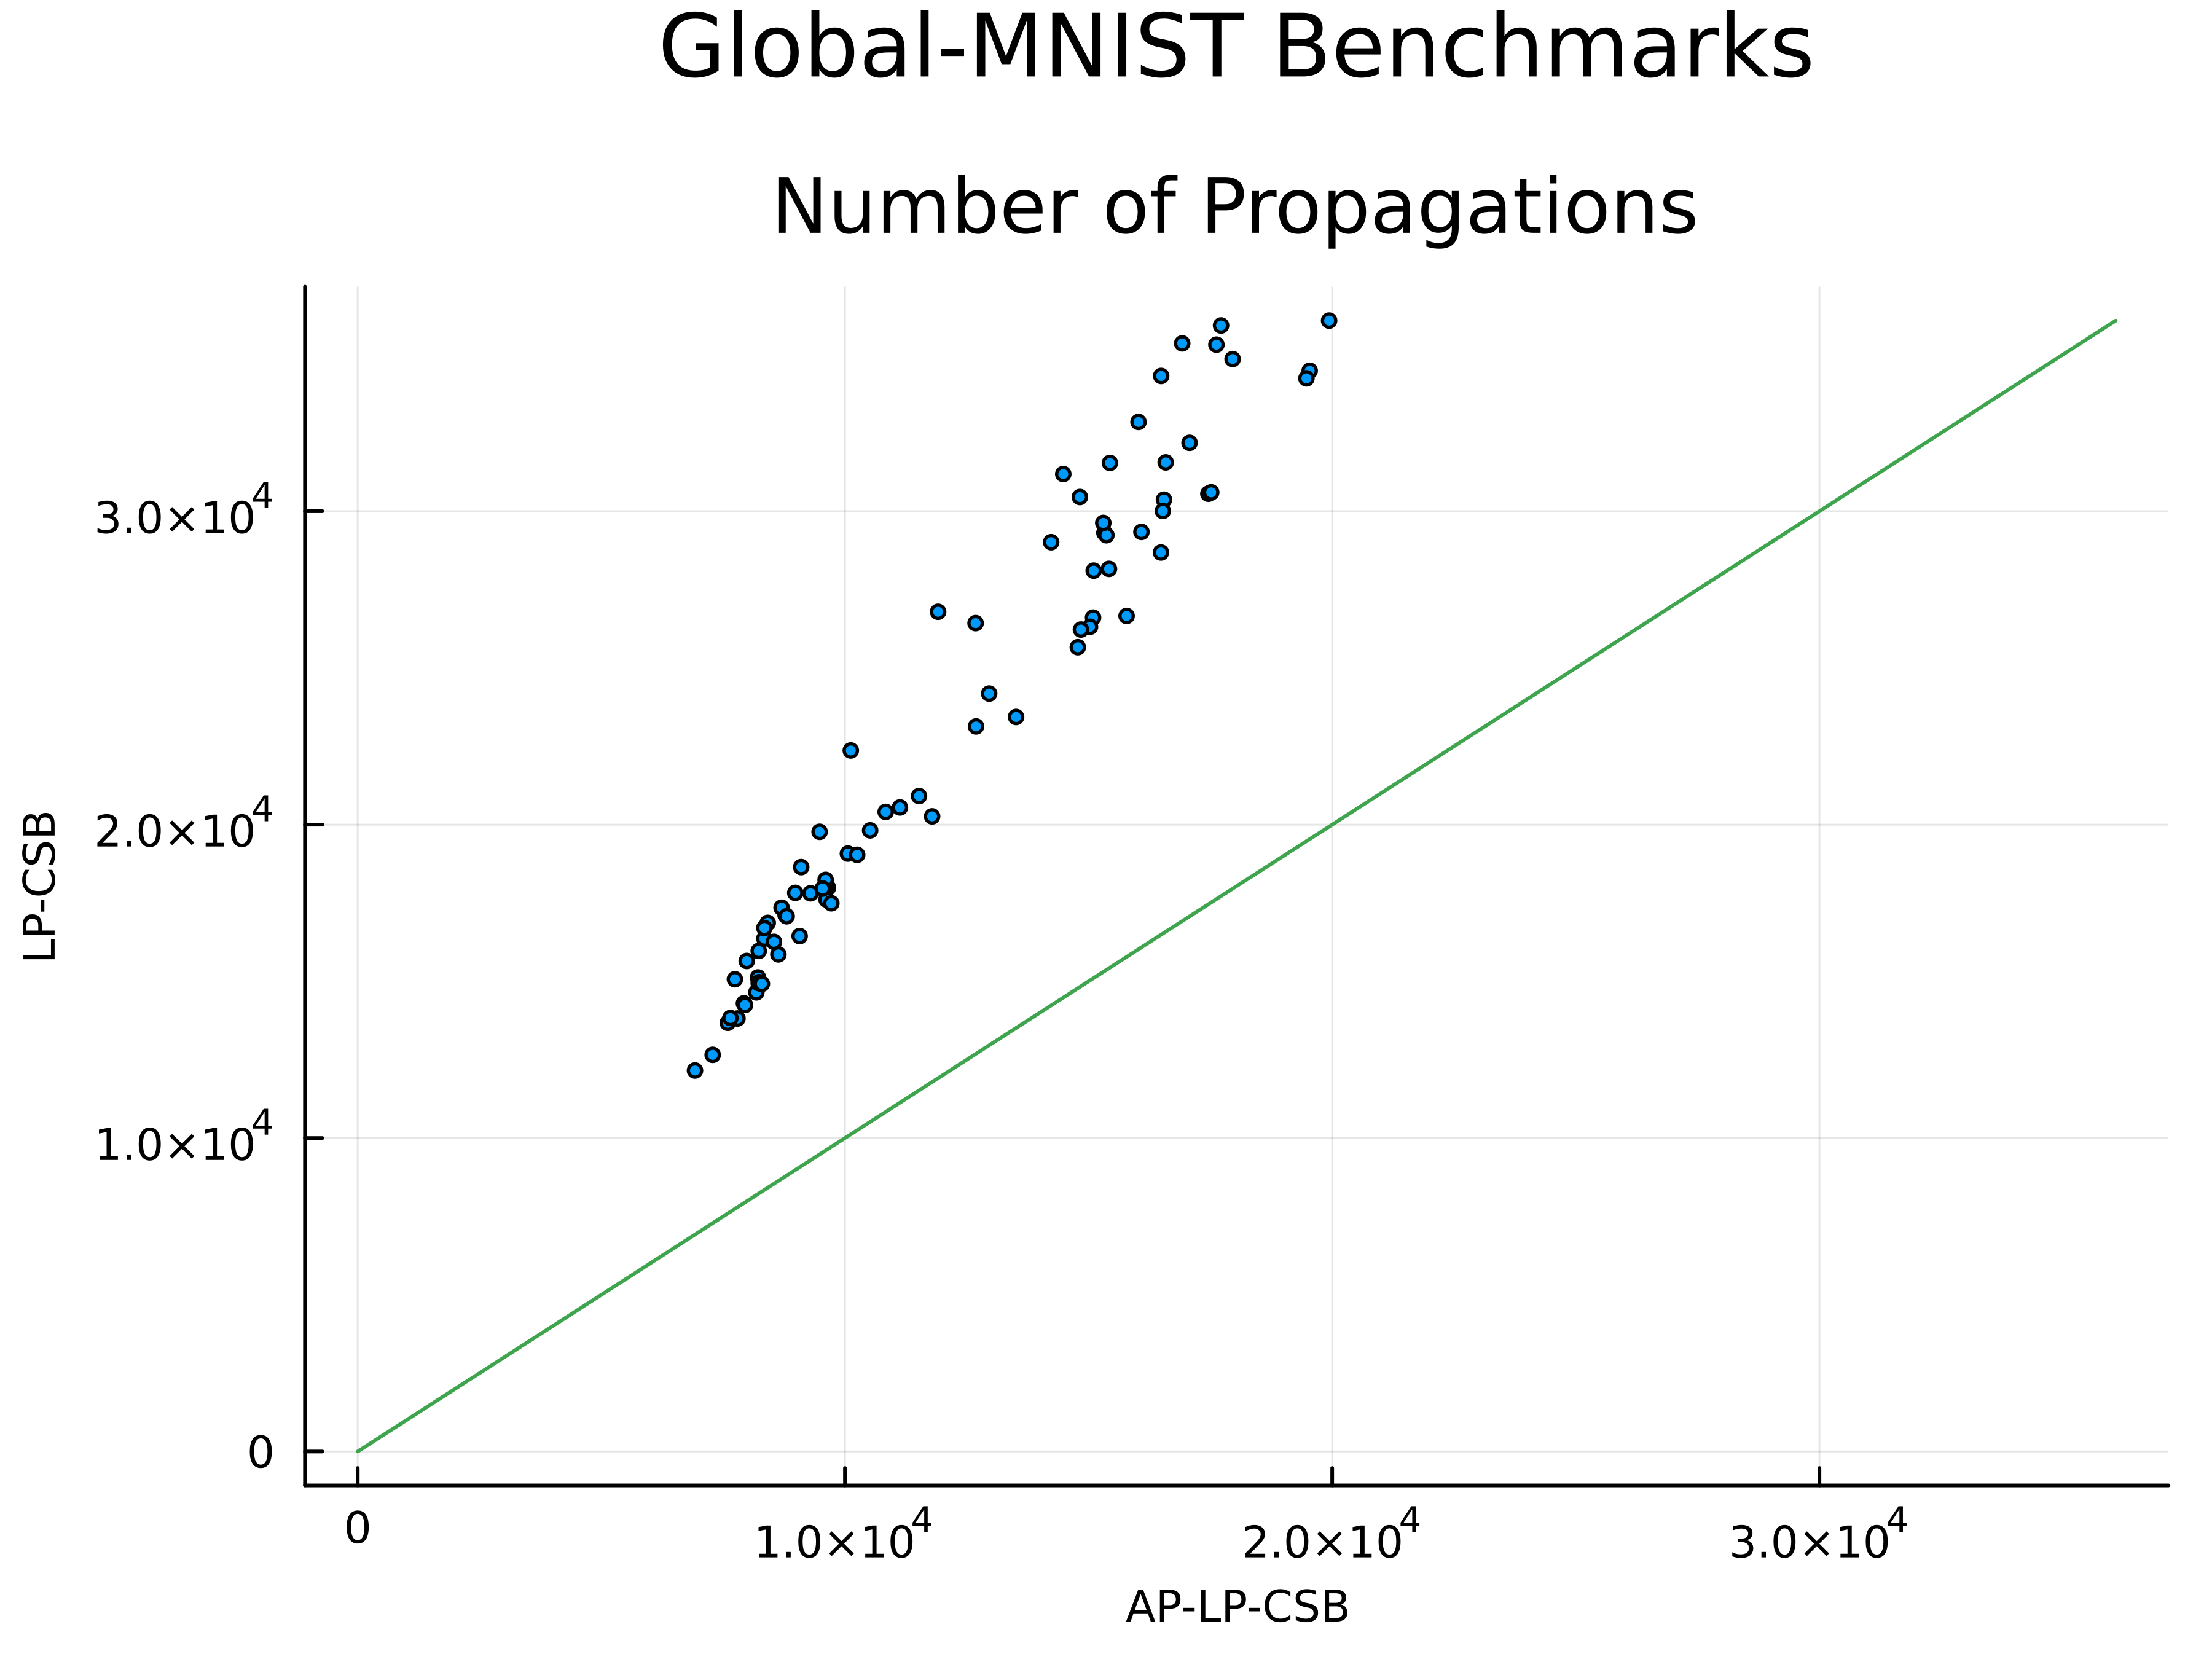

In [ ]:
p = plot(dpi=600, widen=true, legend=false, label=false; layout=grid(1, 1), size=(600, 450))

combinations = [(2, 6)]

for (n, (i, j)) in enumerate(combinations)
    N = 1, 1, 1
    for (k, (name, cfgs)) in enumerate([("Neuron Splitting", neuron_splitting_cfgs)])
        df₁, df₂ = mnist_data[cfgs[i]], mnist_data[cfgs[j]]

        xlabel!(cfgs_names[cfgs[i]], subplot=n)
        ylabel!(cfgs_names[cfgs[j]], subplot=n)

        solved_all = df₁.status .!== "UNKNOWN" .&& df₂.status .!== "UNKNOWN"
        df_solved₁ = df₁[solved_all, :]
        df_solved₂ = df₂[solved_all, :]

        unknown_all = df₁.status .== "UNKNOWN" .&& df₂.status .== "UNKNOWN"
        df_unsolved₁ = df₁[unknown_all, :]
        df_unsolved₂ = df₂[unknown_all, :]

        y₁ = df_unsolved₁.num_propagations
        y₂ = df_unsolved₂.num_propagations

        N = max(maximum(y₁), maximum(y₂))

        scatter!(p, y₁, y₂, markersize=2.0, c=k, subplot=n)
    end
    plot!(p, range(0, N), range(0, N), title="Number of Propagations", label=false, c=3, subplot=n)
end

plot!(p, guidefontsize=8, tickfontsize=8, legendfontsize=3)
plot!(p, plot_title="Global-MNIST Benchmarks", plot_titlevspan=0.1)

# savefig(p, joinpath(eval_mnist_dir, "row_subst", "$(mnist_name)-num_propagations.png"))
# savefig(p, joinpath(eval_mnist_dir, "row_subst", "$(mnist_name)-num_propagations.pdf"))

p

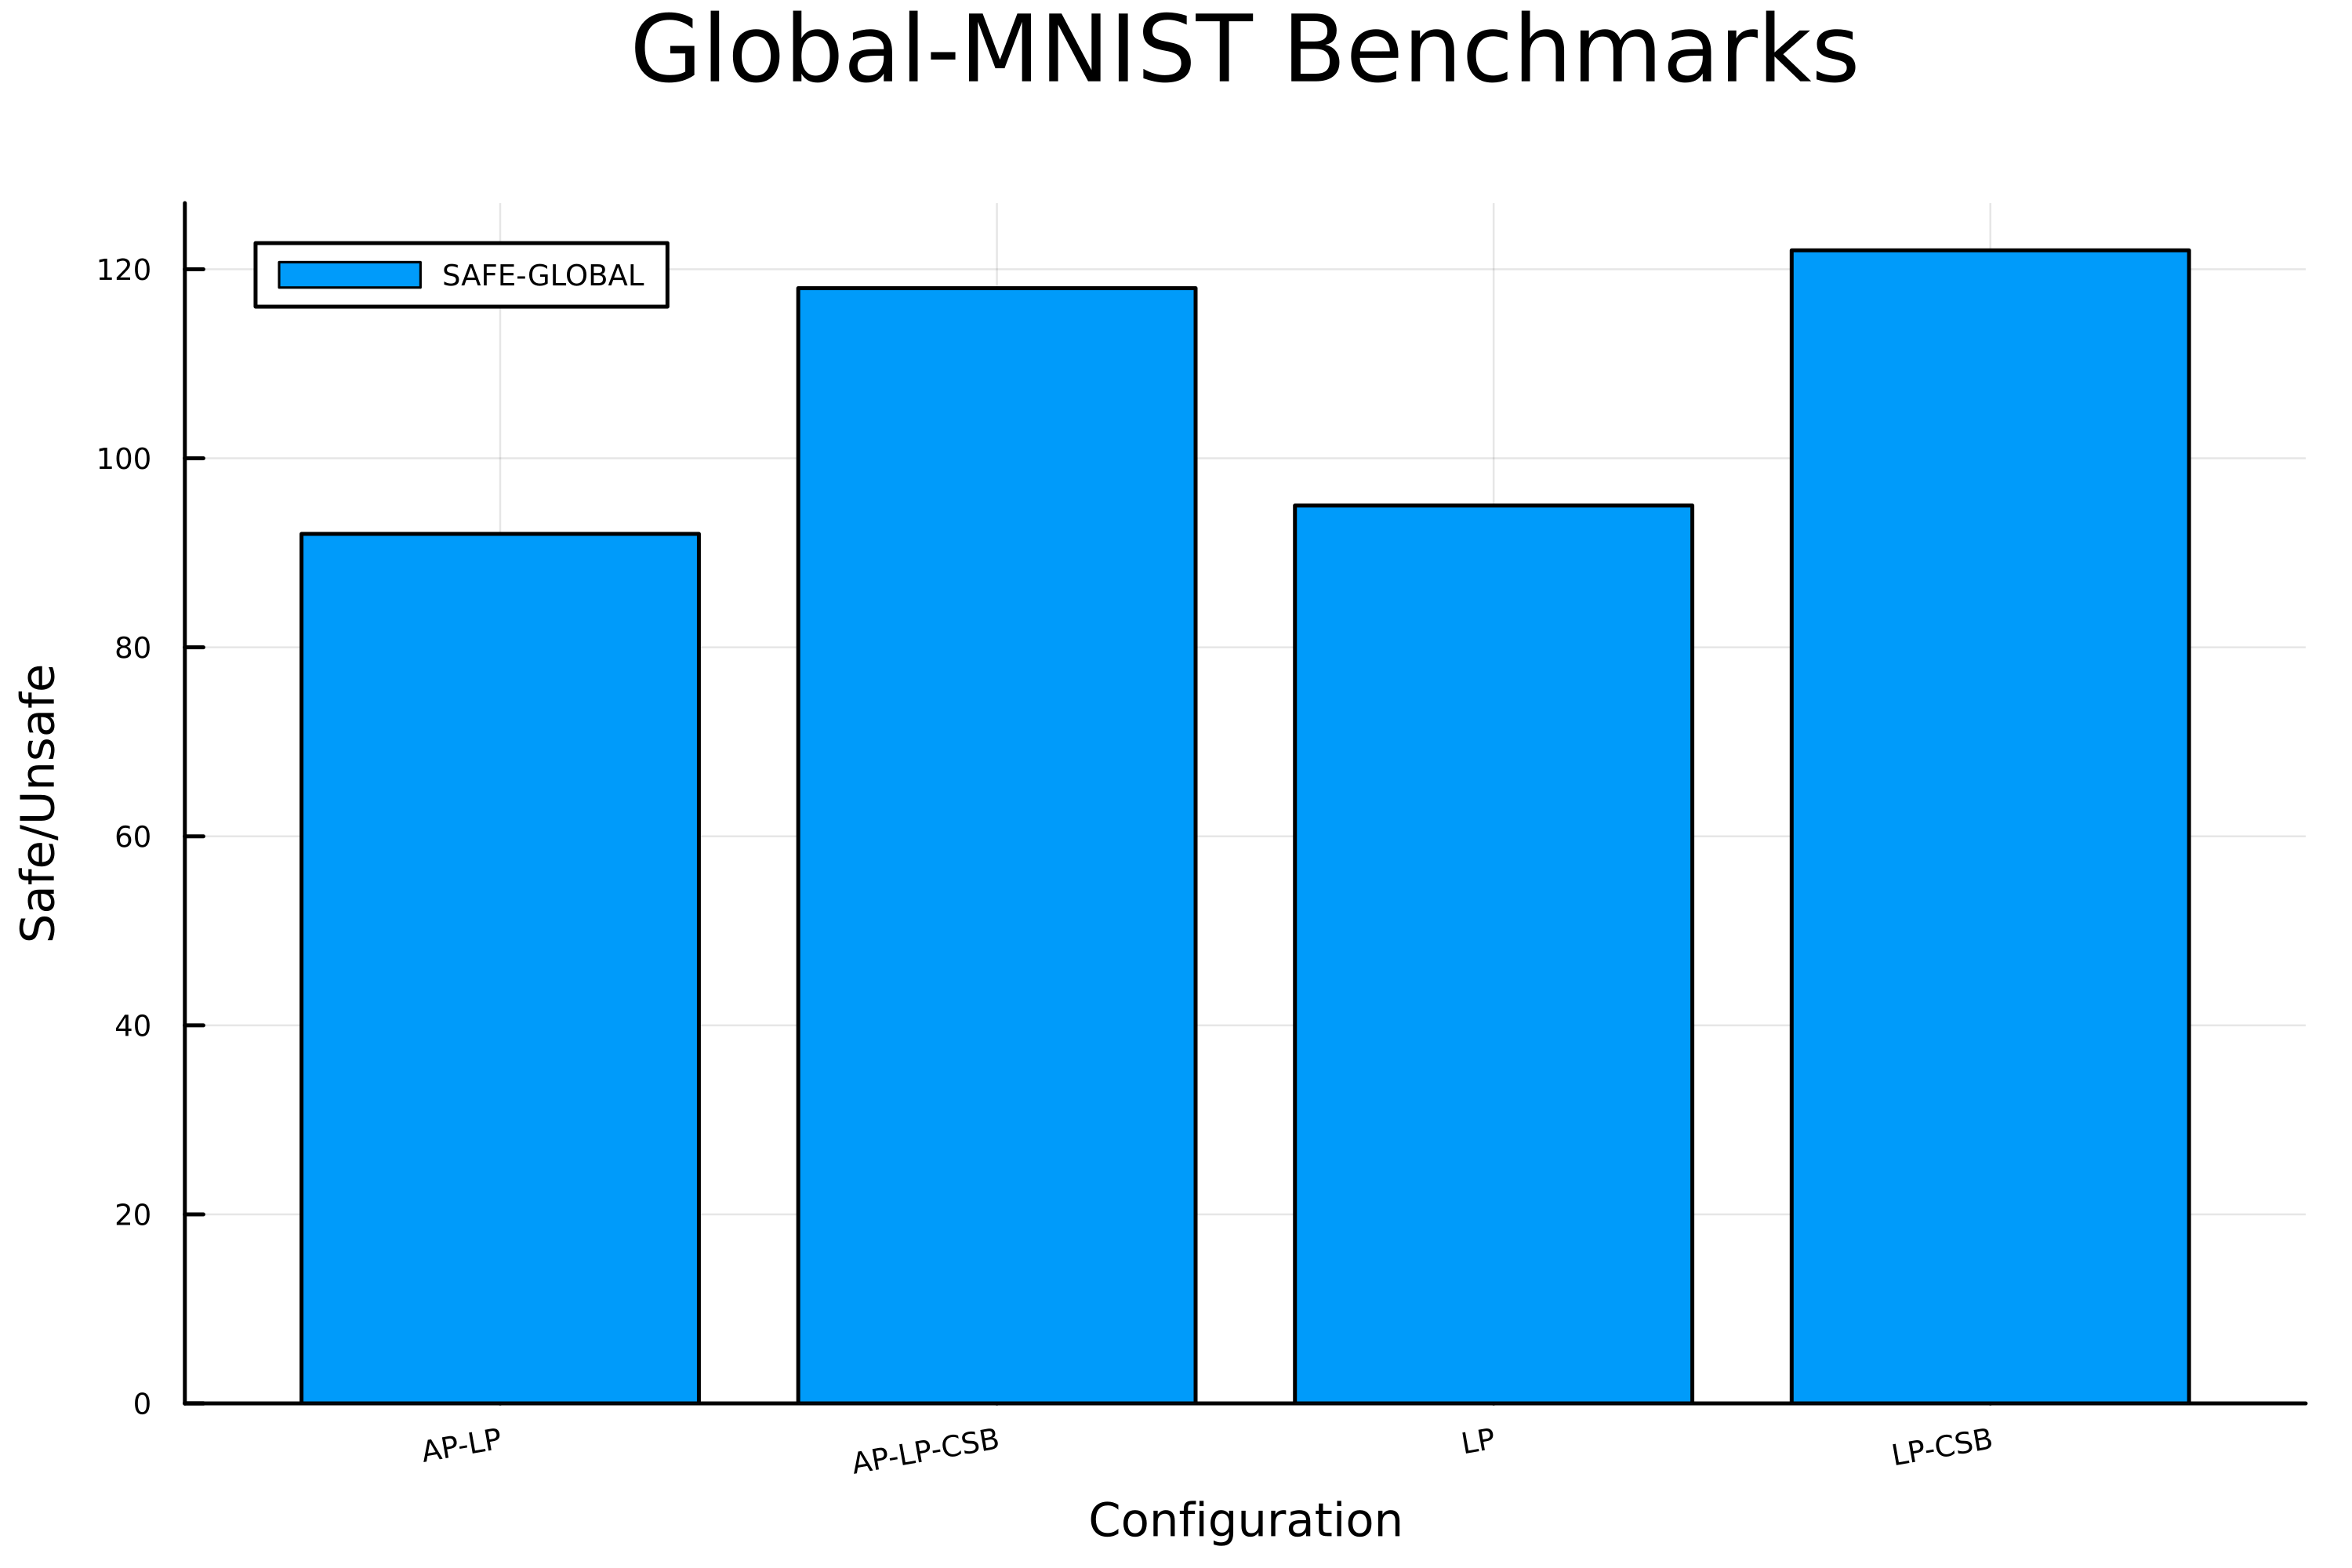

In [10]:
p = plot(dpi=500, widen=true, legend=false, xlabel="Configuration", ylabel="Safe/Unsafe"; layout=1)
max_y = 0
# for (i, (name, configs)) in enumerate(all_configs)
for (i, (name, configs)) in enumerate([("Neuron Splitting", neuron_splitting_cfgs)])
    df = DataFrame()
    temp = DataFrame()
    for config in configs
        df_local_global_group = transform(
            mnist_data[config], 
            [:status, :spec] => ByRow((x, y) -> ifelse(contains(y, "local"), "$x-LOCAL", "$x-GLOBAL")) => "group"
        )
        df_num_iter_group = transform(
            mnist_data[config],
            [:status, :num_propagations] => ByRow((x, y) -> ifelse(y > 1, "$x-NUM_ITERS > 1", "$x-NUM_ITERS == 1")) => "group"
        )

        df_group = vcat(df_local_global_group, df_num_iter_group)
        temp = combine(groupby(df_local_global_group, :group), nrow => :count)
        temp = temp[.!(contains.(temp.group, "UNKNOWN")), :]
        temp[!, "config"] .= config
        temp = temp[contains.(temp.config, "LP"), :]
        df = vcat(df, temp)
        max_y = max(max_y, sum(temp.count))
    end
    # max_y = max(max_y, maximum(df.count))
    names = map(c -> cfgs_names[c], df.config)
    groupedbar!(names, df.count, group=df.group, bar_position=:stack, subplot=i)
end
plot!(p, plot_title="Global-MNIST Benchmarks", plot_titlevspan=0.1)
plot!(p, guidefontsize=8, tickfontsize=5, xrotation=10)
plot!(p, legend=:best, legendfontsize=5, subplot=1)
plot!(p, ylims=(0, max_y+5))

# mkdir(joinpath(eval_mnist_dir, "row_subst"))
# savefig(p, joinpath(eval_mnist_dir, "row_subst", "$mnist_name-hist.pdf"))
# savefig(p, joinpath(eval_mnist_dir, "row_subst", "$mnist_name-hist.png"))

p

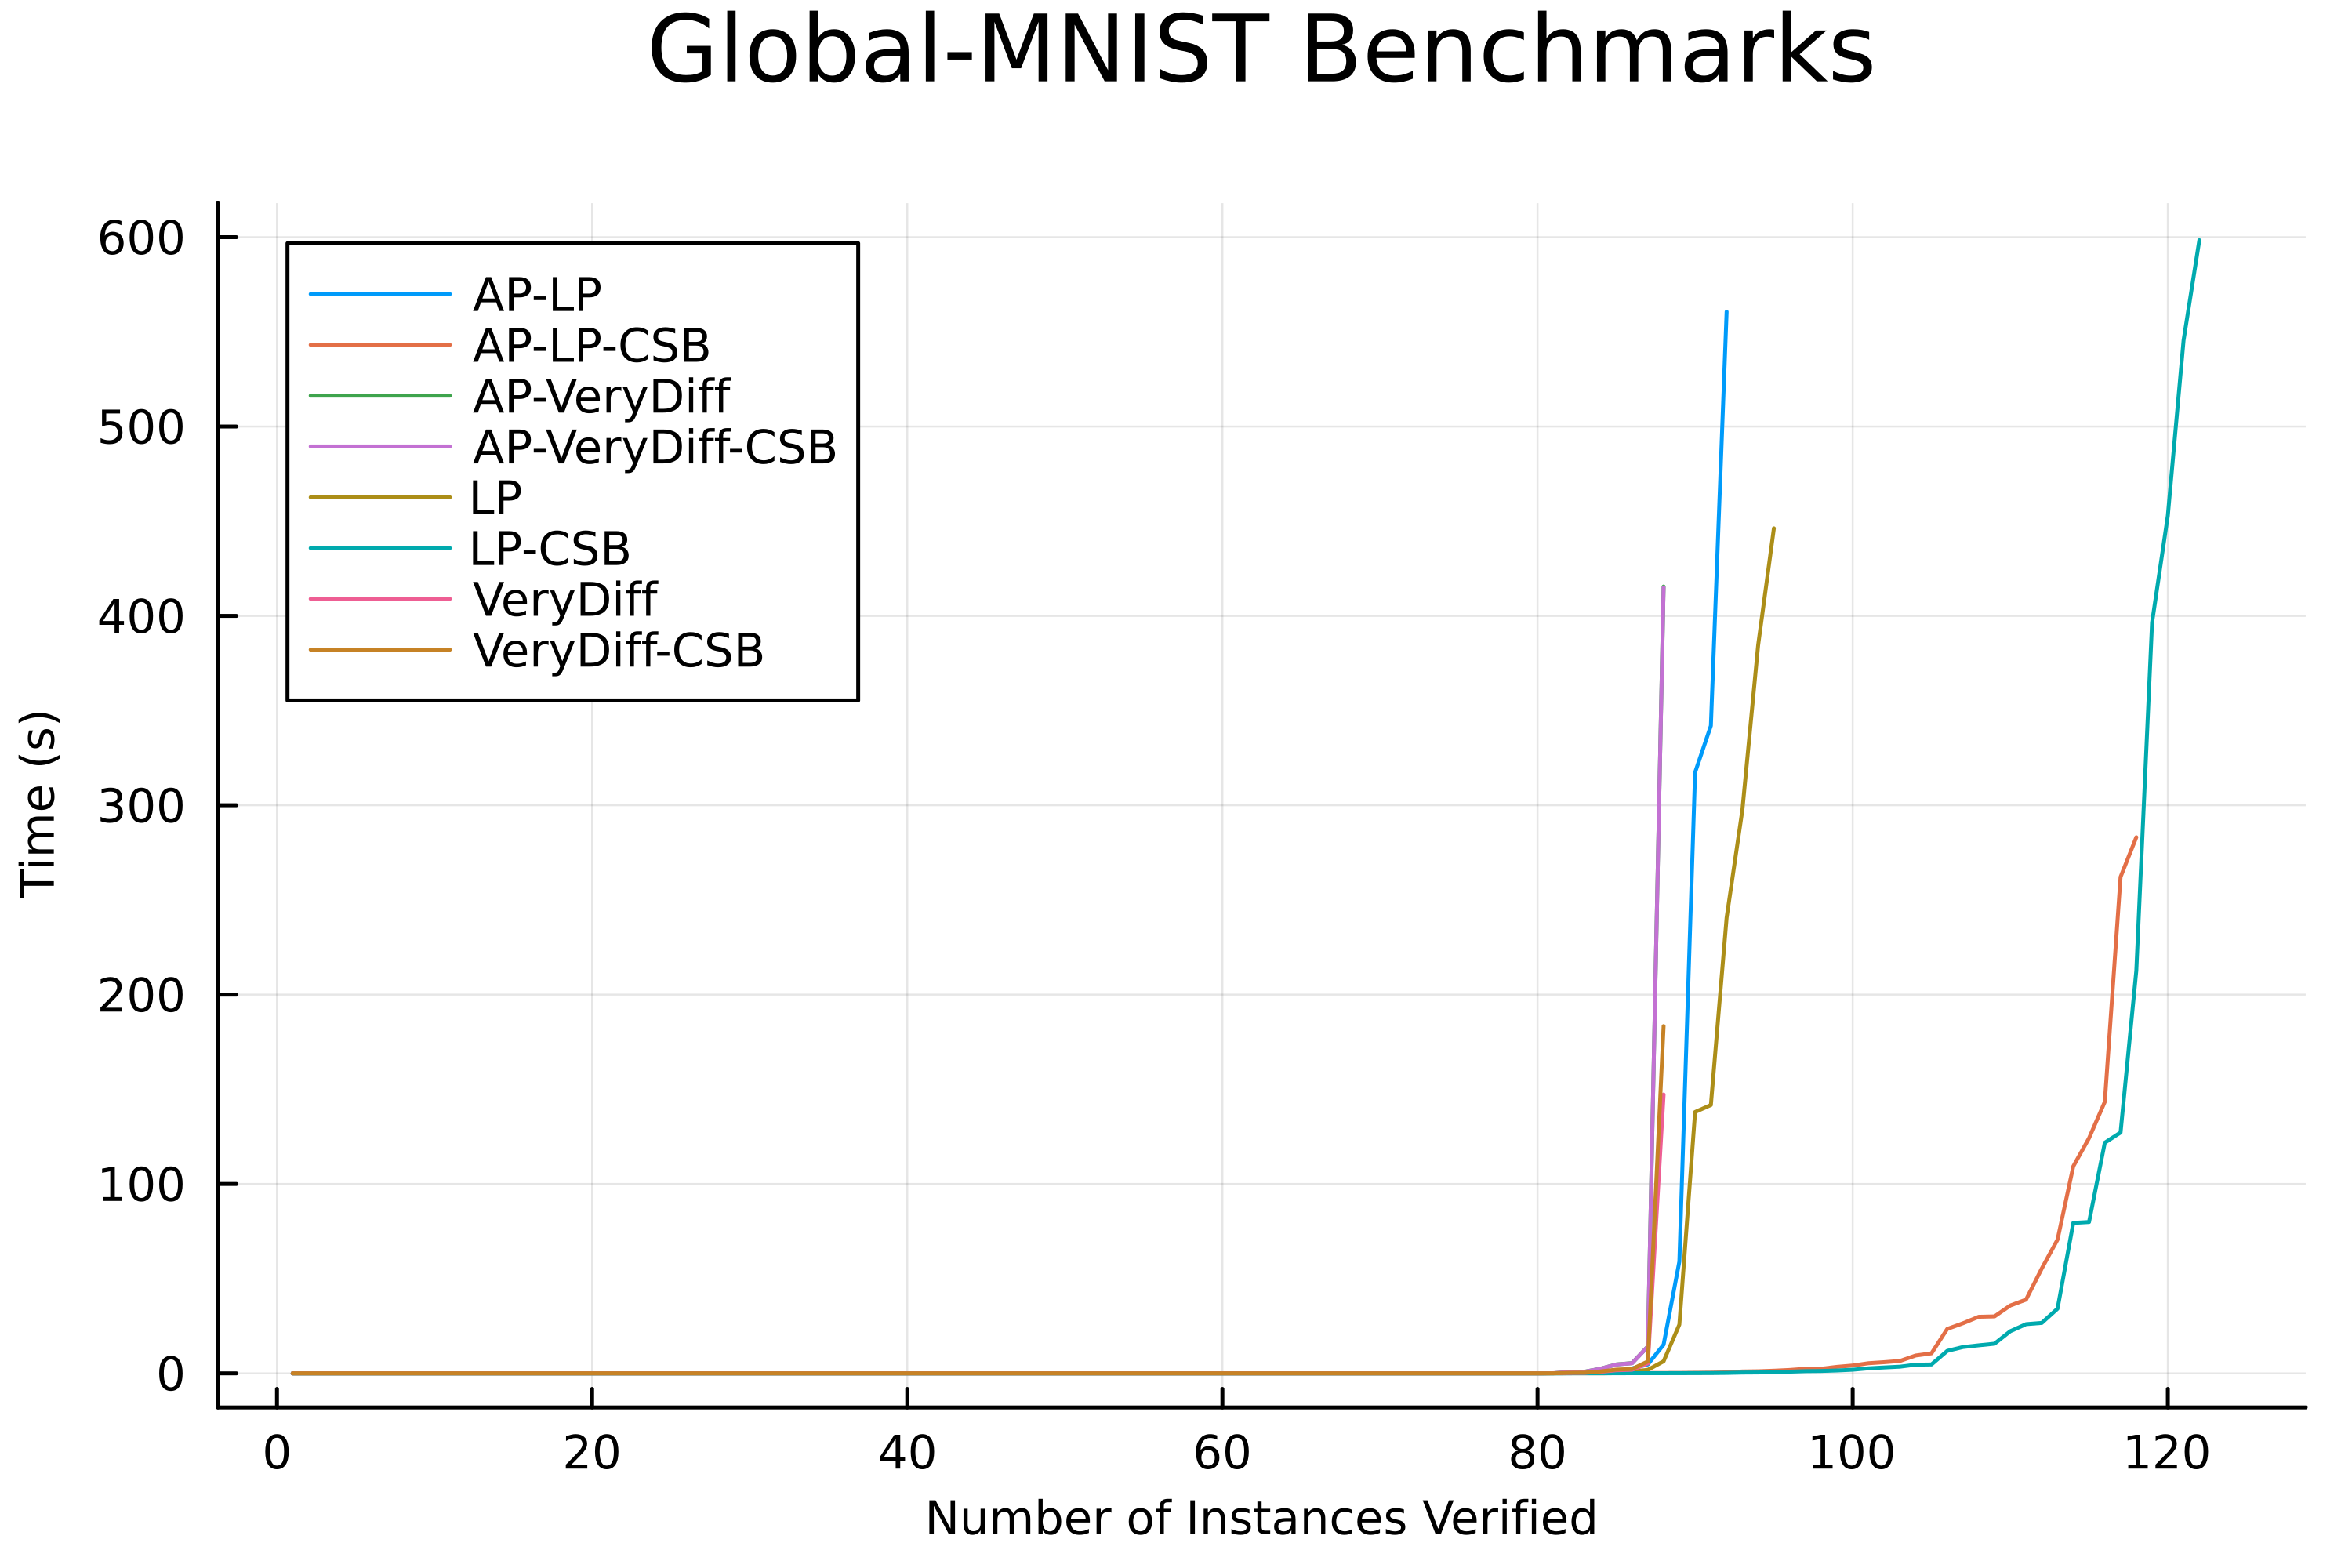

In [8]:
p = plot(dpi=500, xlims=(0, 125), ylims=(0, 600), widen=true, titlefontsize=10, xguidefontsize=8, yguidefontsize=8, legend=false; layout=1)
xlabel!("Number of Instances Verified")
ylabel!("Time (s)")

titles = ["Neuron Splitting", "Neuron + Input Splitting"]
for (i, (name, cfgs)) in enumerate([("Neuron Splitting", neuron_splitting_cfgs)])
    cfgs_data = map(c -> mnist_data[c], cfgs)
    cfgs_solved = filter.(c -> c.status != "UNKNOWN", cfgs_data)
    # cfgs_unsat = filter.(c -> c.status == "UNSAFE", cfgs_solved)
    # cfgs_sat = filter.(c -> c.status == "SAFE", cfgs_solved)
    runtimes = map(c -> c.runtime / 1e9, cfgs_solved)
    runtimes = sort.(runtimes)
    for (j, runtime) in enumerate(runtimes)
        # plot!(p, runtime, title=titles[i], label=cfgs_names[cfgs[j]], subplot=i)
        plot!(p, runtime, label=cfgs_names[cfgs[j]], subplot=i)
    end
end

plot!(p, subplot=1, legend=:topleft)
plot!(p, plot_title="Global-MNIST Benchmarks", plot_titlevspan=0.1)

# savefig(p, joinpath(eval_mnist_dir, "row_subst", "$mnist_name.pdf"))
# savefig(p, joinpath(eval_mnist_dir, "row_subst", "$mnist_name.png"))

p

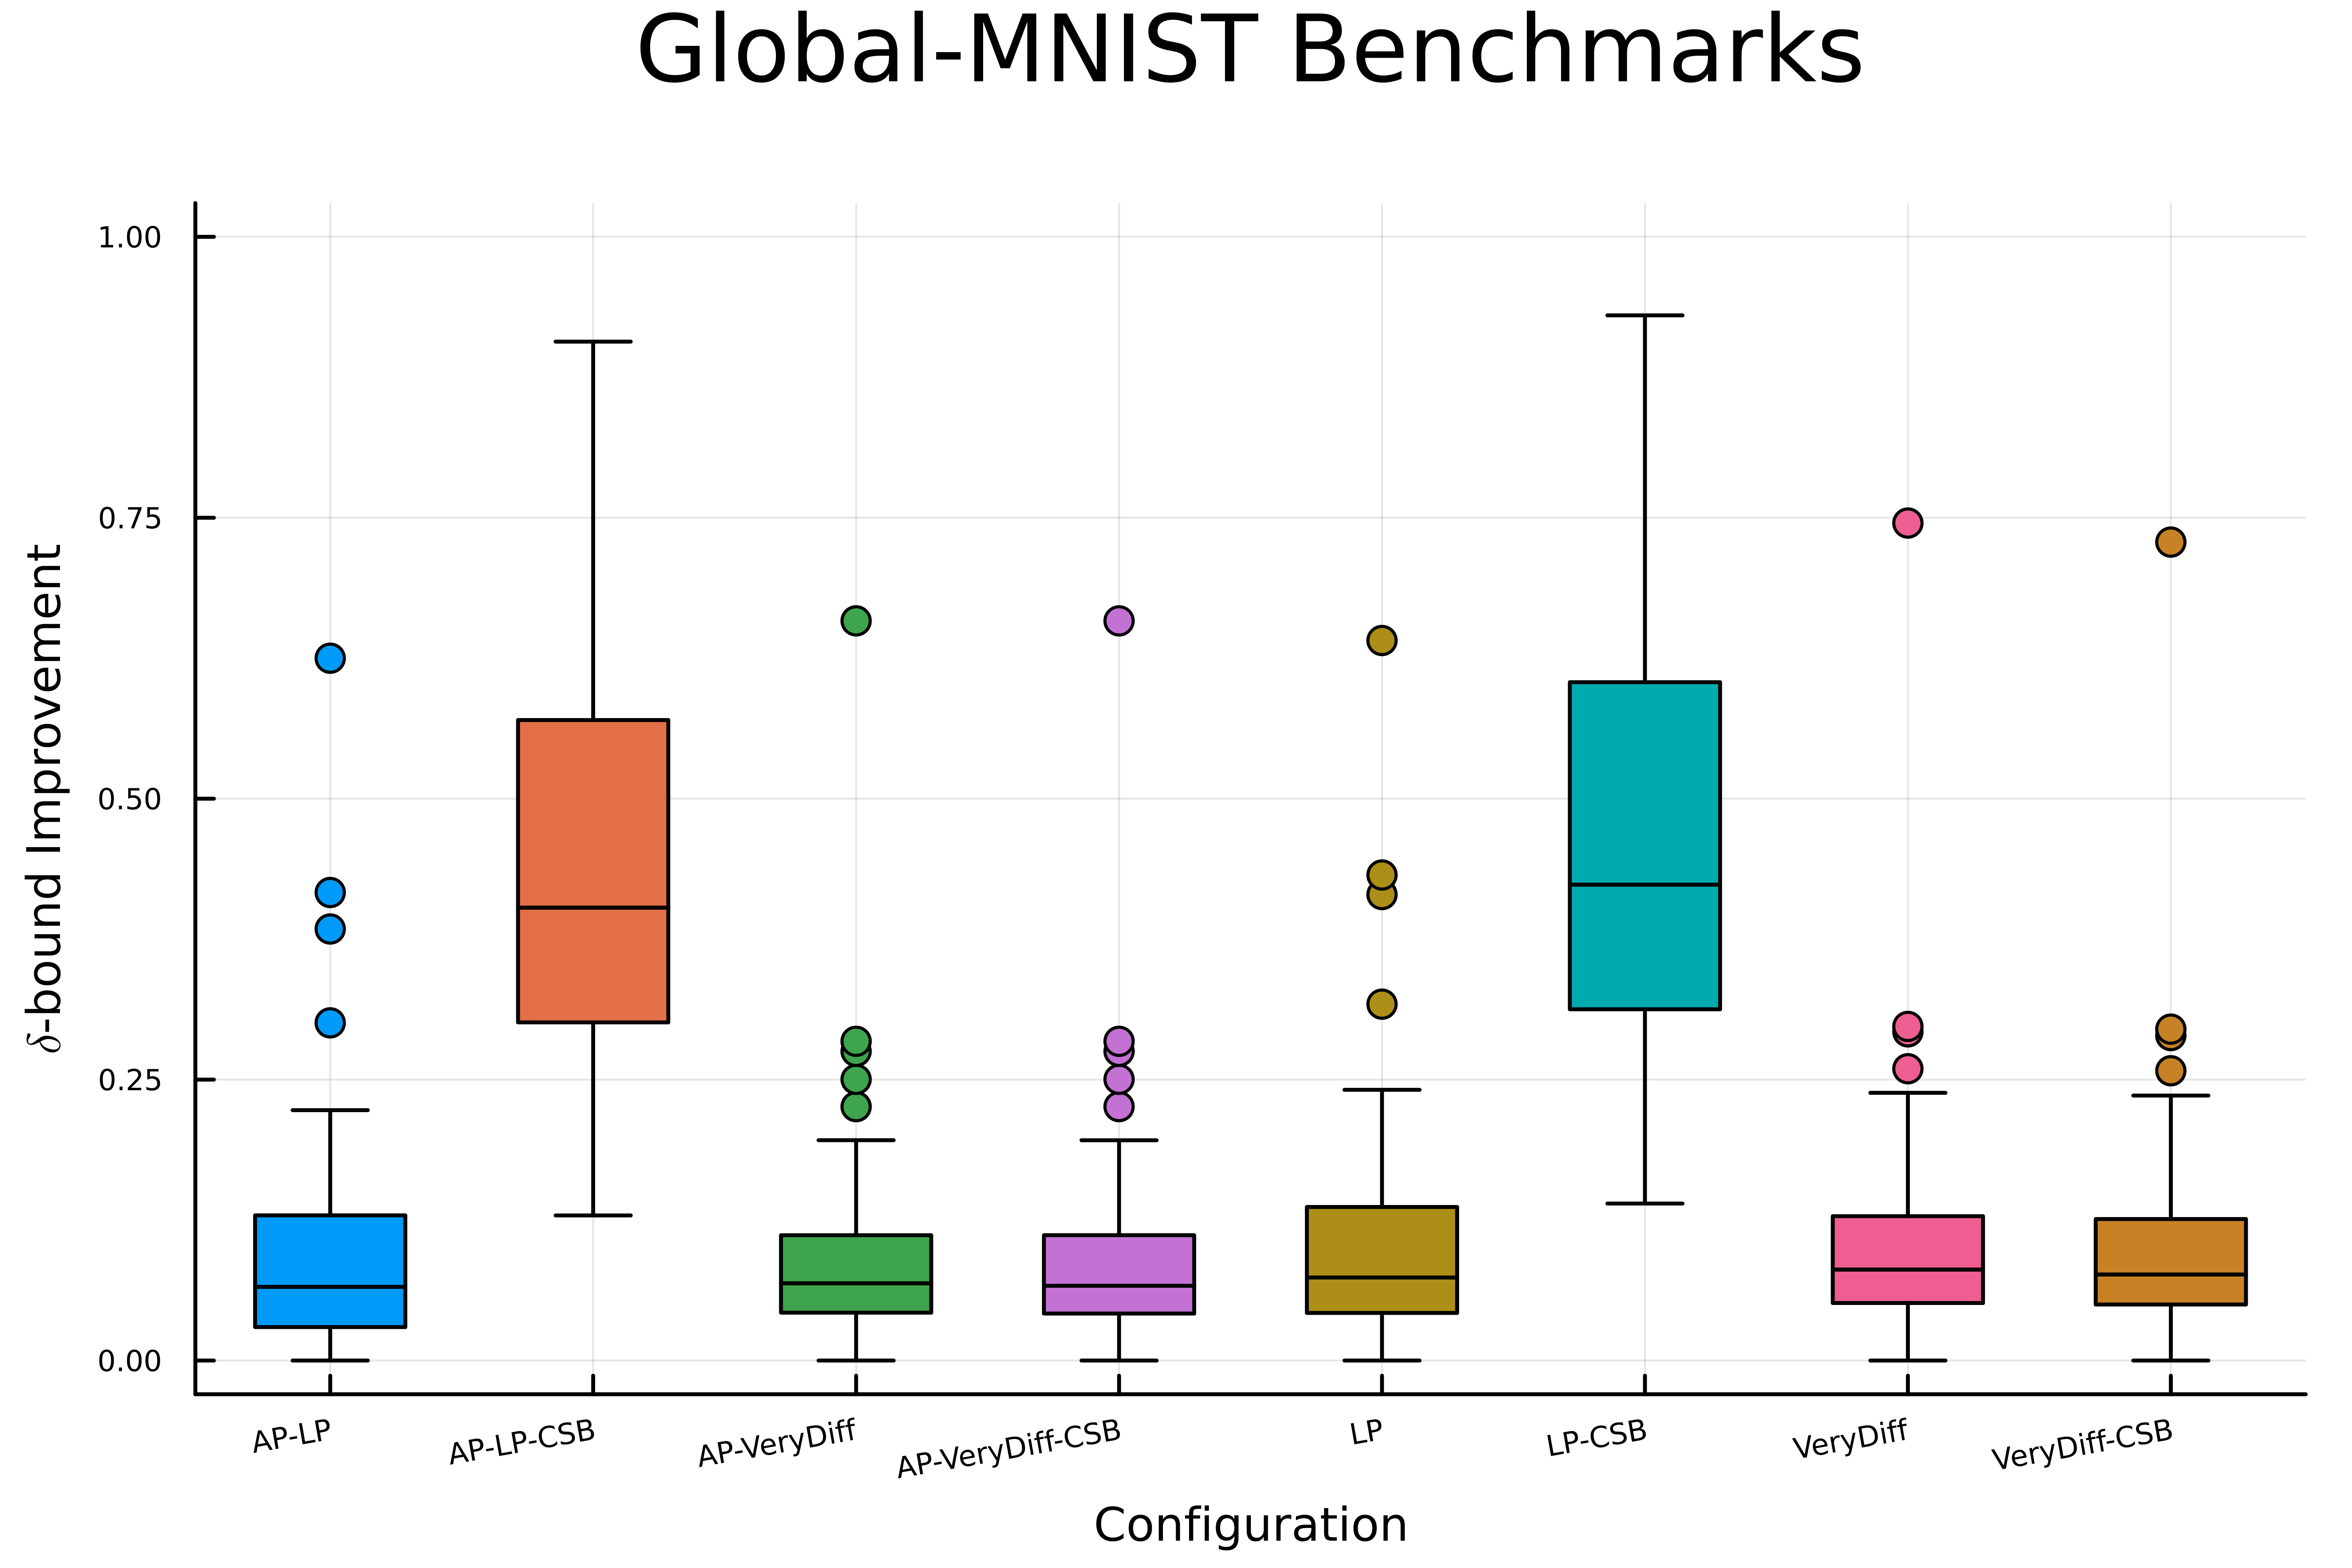

In [11]:
p = boxplot(dpi=1000, widen=true, titlefontsize=10, xguidefontsize=5, yguidefontsize=5, legend=false; layout=1)
xlabel!("Configuration")
ylabel!(L"δ" * "-bound Improvement")

titles = ["Neuron Splitting", "Neuron + Input Splitting"]
for (i, (name, cfgs)) in enumerate([("Neuron Splitting", neuron_splitting_cfgs)])
    unsolved_mask = mapfoldl(c -> mnist_data[c].status .== "UNKNOWN", (x, y) -> x .&& y, cfgs)
    improvements = mapreduce(cfg -> sort(δ_bound_improvement.(Tables.namedtupleiterator(mnist_data[cfg][unsolved_mask, :]), 1.0)), hcat, cfgs)
    # boxplot!(p, mapreduce(c -> cfgs_names[c], hcat, cfgs), improvements, title=titles[i], subplot=i)
    boxplot!(p, mapreduce(c -> cfgs_names[c], hcat, cfgs), improvements, subplot=i)
end

ylims!(0, 1)
boxplot!(p, subplot=1, legend=false)
boxplot!(p, plot_title="Global-MNIST Benchmarks", plot_titlevspan=0.1)
plot!(p, guidefontsize=8, tickfontsize=5, xrotation=10)

# savefig(p, joinpath(eval_mnist_dir, "row_subst", "$mnist_name-boxplot.pdf"))
# savefig(p, joinpath(eval_mnist_dir, "row_subst", "$mnist_name-boxplot.png"))

p

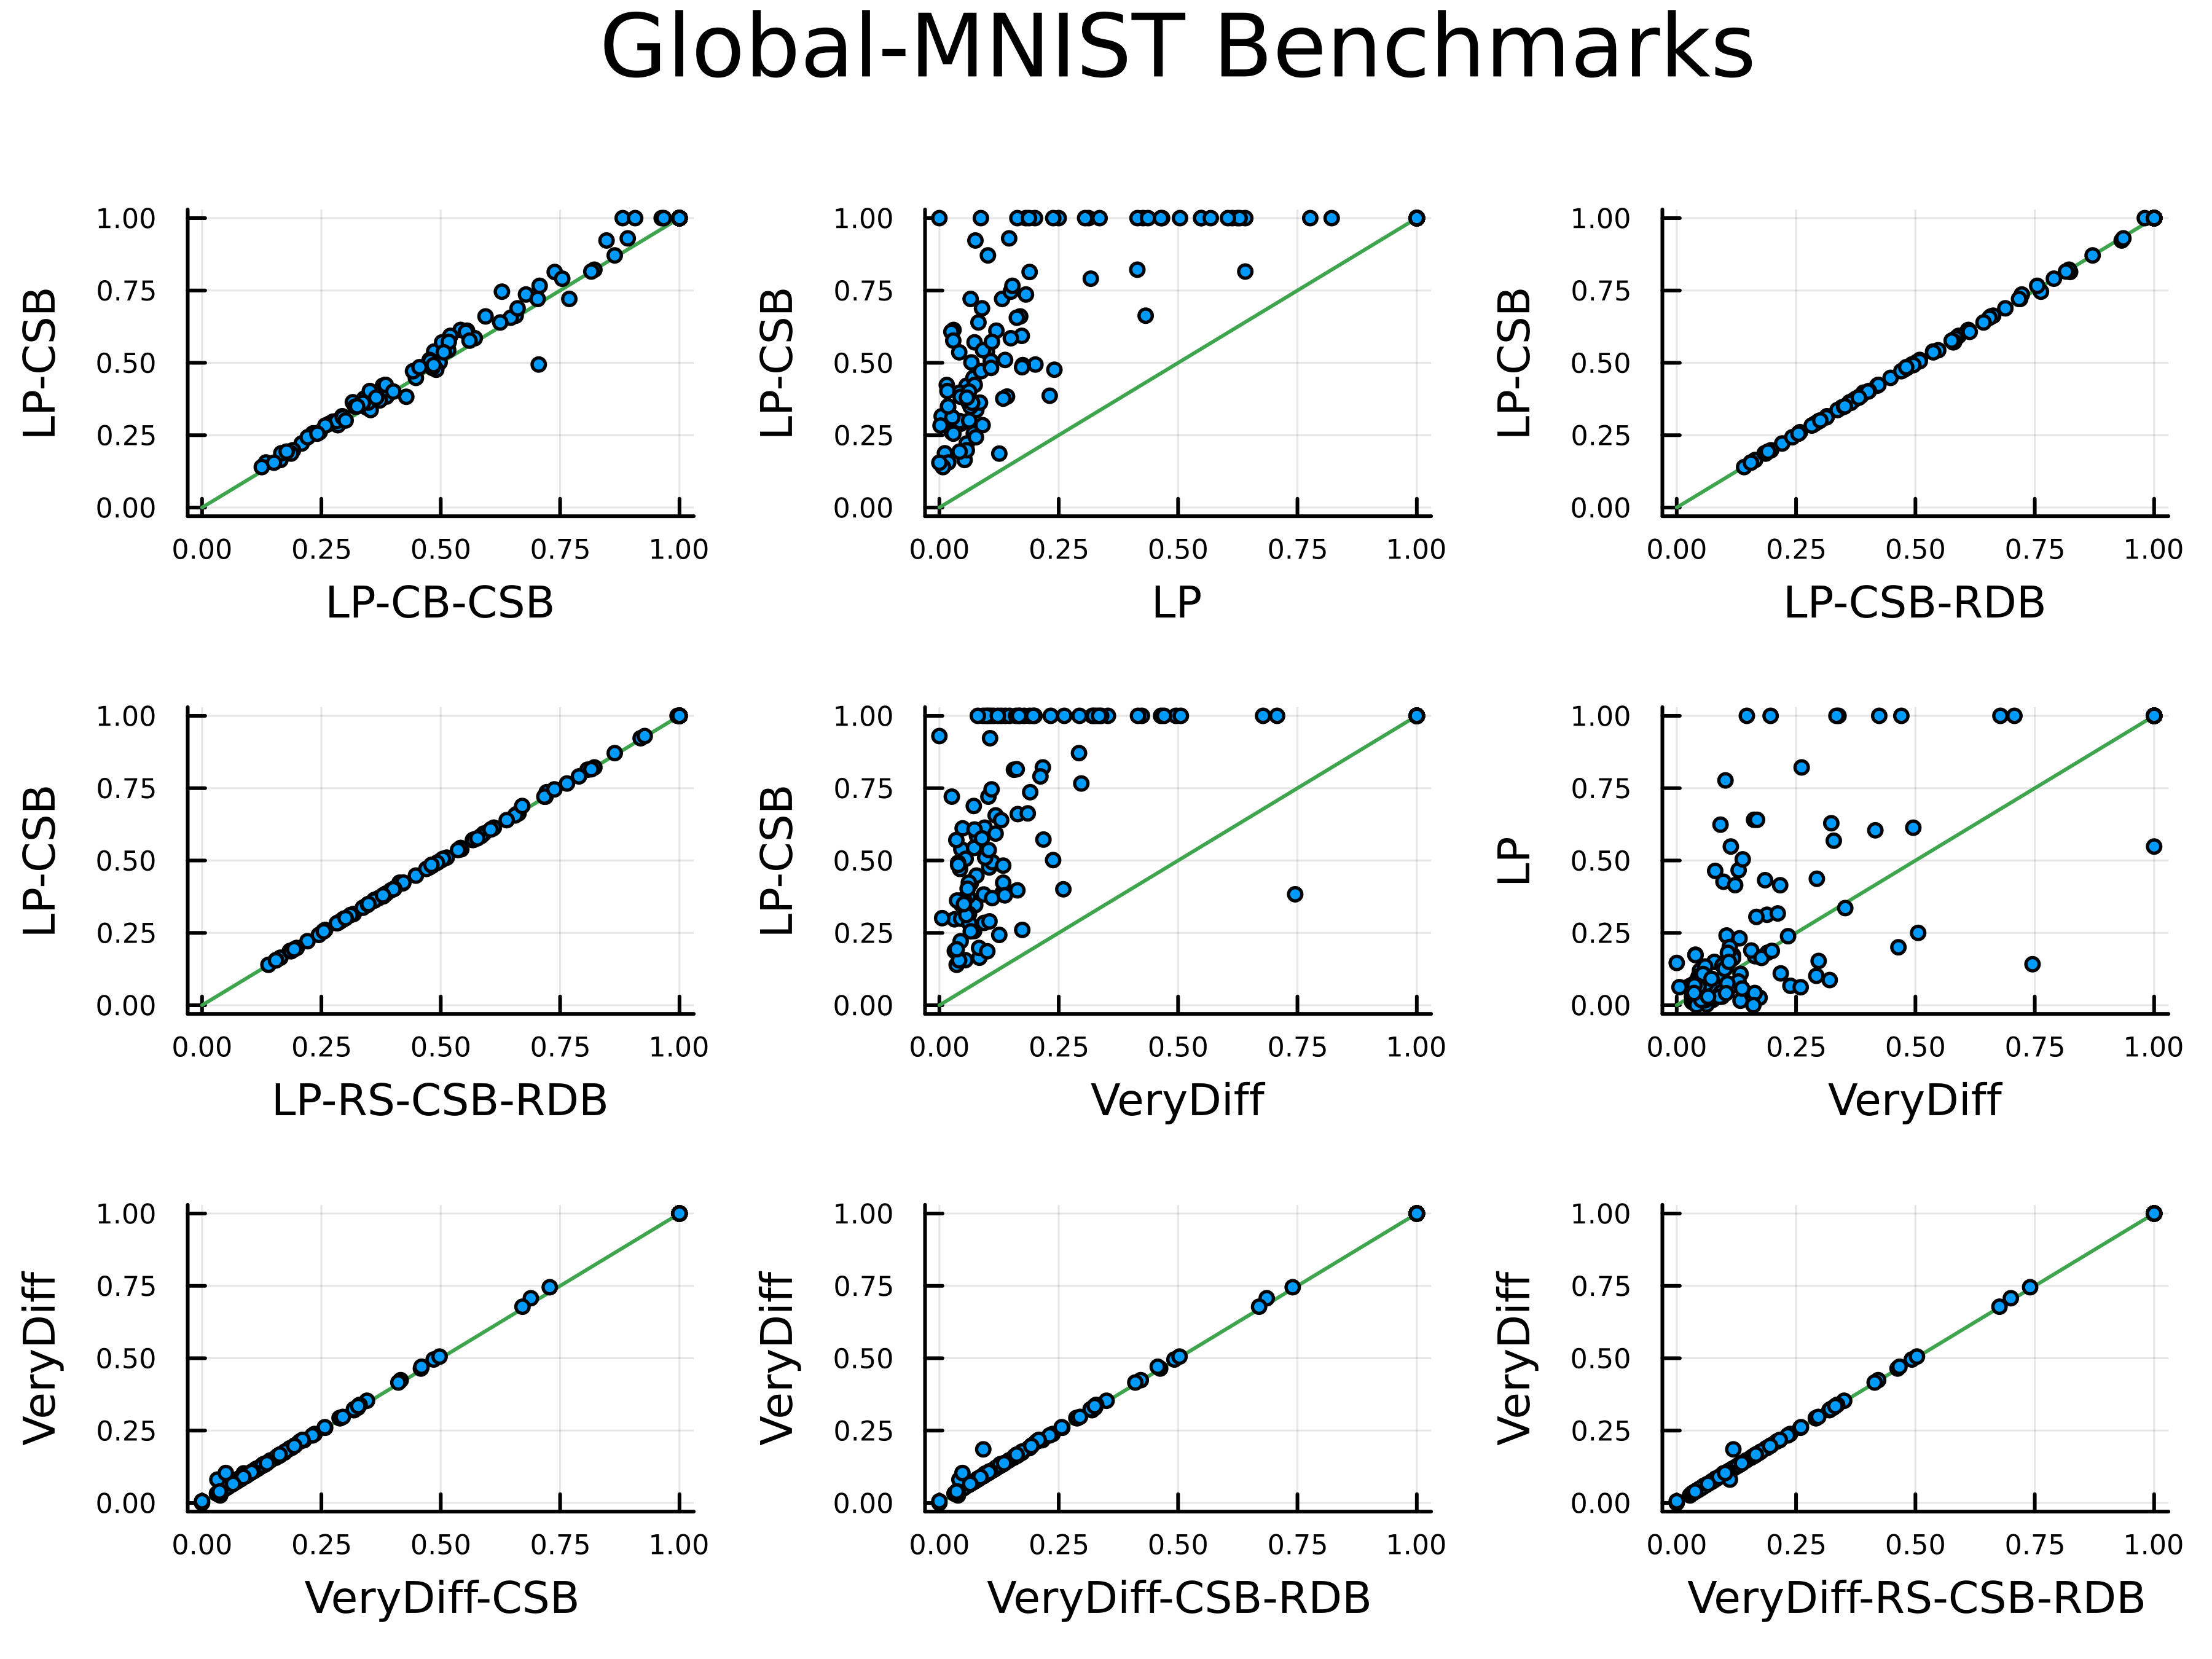

In [22]:
p = plot(dpi=600, xlims=(0, 1), ylims=(0, 1), widen=true, legend=false, label=false; layout=grid(3, 3), size=(600, 450))

labels = ["Neuron Splitting" "Neuron + Input Splitting"]
# combinations = [(2, 1), (3, 2), (6, 2), (2, 7), (3, 7), (6, 7), (4, 6), (3, 6), (5, 6)]
# combinations = [(2, 1), (3, 1), (3, 7), (5, 4), (6, 4), (6, 3), (8, 7), (9, 7), (6, 7)]
# combinations = [(3, 1), (3, 2), (3, 4), (3, 9), (7, 5), (7, 6), (7, 8), (7, 3), (9, 10), (9, 11), (9, 12), (9, 7)]
# combinations = [(1, 2), (1, 3), (2, 3)]
combinations = [(1, 3), (2, 3), (4, 3), (5, 3), (6, 3), (6, 2), (7, 6), (8, 6), (9, 6)]

for (n, (i, j)) in enumerate(combinations)
    plot!(p, range(0, 1), range(0, 1), label=false, c=3, subplot=n)

    for (k, (name, cfgs)) in enumerate([("Neuron Splitting", neuron_splitting_cfgs)])
    # for (k, cfgs) in enumerate(all_cfgs)
        xlabel!(cfgs_names[cfgs[i]], subplot=n)
        ylabel!(cfgs_names[cfgs[j]], subplot=n)
        
        y₁ = δ_bound_improvement.(Tables.namedtupleiterator(mnist_data[cfgs[i]]), 1.0)
        y₂ = δ_bound_improvement.(Tables.namedtupleiterator(mnist_data[cfgs[j]]), 1.0)

        scatter!(p, y₁, y₂, markersize=2.0, c=k, subplot=n)
    end
end

# scatter!(p, subplot=1, label=labels, legend=:bottomright)
plot!(p, guidefontsize=8, tickfontsize=5, legendfontsize=3)
plot!(p, plot_title="Global-MNIST Benchmarks", plot_titlevspan=0.1)

savefig(p, joinpath(eval_mnist_dir, "row_subst", "$mnist_name-bounds.pdf"))
savefig(p, joinpath(eval_mnist_dir, "row_subst", "$mnist_name-bounds.png"))

p

In [ ]:
acas_data = Dict(c => CSV.read(acas_paths[c], DataFrame, header=csv_title, delim=", ") for c in configs)

In [ ]:
p = plot(dpi=500, widen=true, legend=false, xlabel="Configuration", ylabel="Safe/Unsafe"; layout=2)
max_y = 0
for (i, (name, configs)) in enumerate(all_configs)
    df = DataFrame()
    temp = DataFrame()
    for config in configs
        temp = transform(acas_data[config], :status => "group")
        temp = combine(groupby(temp, :group), nrow => :count)
        temp = temp[.!(contains.(temp.group, "UNKNOWN")), :]
        temp[!, "config"] .= config
        df = vcat(df, temp)
    end
    names = map(c -> cfgs_names[c], df.config)
    max_y = max(max_y, maximum(df.count))
    groupedbar!(names, df.count, group=df.group, bar_position=:dodge, title=name, subplot=i)
end
plot!(p, plot_title="ACAS Benchmarks", plot_titlevspan=0.1)
plot!(p, xguidefontsize=8, yguidefontsize=8, xtickfontsize=5)
plot!(p, legend=:best, legendcolumns=2, subplot=1)
plot!(p, ylims=(0, max_y+10))

savefig(p, "$eval_acas_dir/$(acas_name)-hist.pdf")

p

In [ ]:
all_cfgs = [neuron_splitting_cfgs, input_splitting_cfgs]
p = plot(dpi=500, xlims=(0, 100), ylims=(0, 120), widen=true, titlefontsize=10, xguidefontsize=8, yguidefontsize=8, legend=false; layout=2)
xlabel!("Number of Instances Verified")
ylabel!("Time (s)")

titles = ["Neuron Splitting", "Neuron + Input Splitting"]
for (i, cfgs) in enumerate(all_cfgs)
    runtimes = map(c -> c.runtime / 1e9, filter.(c -> c.status != "UNKNOWN", map(c -> acas_data[c], cfgs)))
    runtimes = sort.(runtimes)
    for (j, runtime) in enumerate(runtimes)
        plot!(p, runtime, title=titles[i], label=cfgs_names[cfgs[j]], subplot=i)
    end
end

plot!(p, subplot=1, legend=:topleft)
plot!(p, plot_title="ACAS Benchmarks", plot_titlevspan=0.1)

savefig(p, "$eval_acas_dir/$(acas_name).pdf")

p

In [ ]:
all_cfgs = [neuron_splitting_cfgs, input_splitting_cfgs]
num_cfgs = size(all_cfgs, 1)
p = boxplot(dpi=500, widen=true, titlefontsize=10, xguidefontsize=5, yguidefontsize=5, legend=false; layout=num_cfgs)
xlabel!("Configuration")
ylabel!(L"δ" * "-bound Improvement")

titles = ["Neuron Splitting", "Neuron + Input Splitting"]
for (i, cfgs) in enumerate(all_cfgs)
    unsolved_mask = mapfoldl(c -> acas_data[c].status .== "UNKNOWN", (x, y) -> x .&& y, cfgs)
    improvements = mapreduce(cfg -> sort(δ_bound_improvement.(Tables.namedtupleiterator(acas_data[cfg][:, :]), 0.05)), hcat, cfgs)
    boxplot!(p, mapreduce(c -> cfgs_names[c], hcat, cfgs), improvements, title=titles[i], subplot=i)
end

ylims!(0, 1)
boxplot!(p, subplot=1, legend=false)
boxplot!(p, xguidefontsize=8, yguidefontsize=8, xtickfontsize=5)
boxplot!(p, plot_title="ACAS Benchmarks", plot_titlevspan=0.1)

savefig(p, "$eval_acas_dir/$(acas_name)-boxplot.pdf")

p

In [ ]:
all_cfgs = [neuron_splitting_cfgs, input_splitting_cfgs]
p = plot(dpi=500, xlims=(0, 1), ylims=(0, 1), widen=true, legend=false, label=false; layout=grid(3, 3), size=(500, 450))

labels = ["Neuron Splitting" "Neuron + Input Splitting"]
combinations = [(2, 1), (3, 2), (6, 2), (2, 7), (3, 7), (6, 7), (4, 6), (3, 6), (5, 6)]

for (n, (i, j)) in enumerate(combinations)
    plot!(p, range(0, 1), range(0, 1), label=false, c=3, subplot=n)

    for (k, cfgs) in enumerate(all_cfgs)
        xlabel!(cfgs_names[cfgs[i]], subplot=n)
        ylabel!(cfgs_names[cfgs[j]], subplot=n)
        
        y₁ = δ_bound_improvement.(Tables.namedtupleiterator(acas_data[cfgs[i]]), 0.05)
        y₂ = δ_bound_improvement.(Tables.namedtupleiterator(acas_data[cfgs[j]]), 0.05)

        scatter!(p, y₁, y₂, markersize=2.0, label=labels[k], c=k, subplot=n)
    end
end

scatter!(p, subplot=7, label=labels, legend=:bottomright)
plot!(p, xguidefontsize=8, yguidefontsize=8, xtickfontsize=5, ytickfontsize=5, legendfontsize=3)
plot!(p, plot_title="ACAS Benchmarks", plot_titlevspan=0.1)

savefig(p, "$eval_acas_dir/$(acas_name)-bounds.pdf")

p